# What is the depedency on the mass of the halo?
----

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from get_model_probabilities import *

import scienceplots
plt.style.use(["science","grid"])

Source redshift:1.36


In [21]:
ifilter='concat'
zl=0.305
zs=1.6
critical_density = sigma_critical(zl, zs, Planck18).to(units.Msun/units.kpc/units.kpc)




obs_meta, obs_data = pkl.load(open(f"../data/a2744/obs_data_{ifilter}.pkl","rb"))
ke, kb = lenspack.image.inversion.ks93(obs_data[0][0], obs_data[0][1])

thresh = [0.]
for i in thresh:
    positive_mass = np.sum(gaussian_filter(ke[ke/np.std(kb)>i],2) * critical_density * (20*units.kpc)**2 )
    err_mass_per_pixel = np.std(gaussian_filter(kb[ke/np.std(kb)>i],2) * critical_density * (20*units.kpc)**2 ).value




    err_mass = len(kb[ke/np.std(kb)>i])*err_mass_per_pixel
    err = [ 
        np.log10(positive_mass.value - err_mass/2.),
        np.log10(positive_mass.value + err_mass/2.)
    ]


In [27]:
mass_bin_centers = np.linspace(err[0],err[1],n_mass_bins)


In [30]:
mass_bin_centers

array([14.64553224, 14.71503813, 14.77493955, 14.82757144, 14.87450881])

In [24]:
np.log10(positive_mass.value)

np.float64(14.774939554305192)

In [32]:
n_mass_bins = 5

mass_bin_centers = np.log10(np.linspace(10**err[0],10**err[1],n_mass_bins))

all_results = pkl.load(open(f"pickles/all_models_{ifilter}_results.pkl",'rb'))

domain = {
    'tgt':'darkskies_obs',
    'src':'bahamas_obs'
}



output_name = "pickles/mass_data_dependence.pkl"

#if os.path.isfile(output_name):
#    mass_results = pkl.load(open(output_name, 'rb'))
#else:
    
mass_results = {}


for imass_bin in tqdm(range(n_mass_bins)):
    
    mass_lower = np.log10( 10**mass_bin_centers[imass_bin] - err_mass/2.)
    mass_upper = np.log10( 10**mass_bin_centers[imass_bin] + err_mass/2.)
    
    mass_cut = [mass_lower, mass_upper]
    print(mass_cut)
 
        
    for itgt, target in enumerate(['src','tgt']):
        try: 
            all_thresholds = mass_results[imass_bin][target]['thresholds']
            cross_sections =  mass_results[imass_bin][target]['cross_section']
        except:
            if imass_bin not in mass_results.keys():
                mass_results[imass_bin] = {'mass_cut':mass_cut}
                
            all_thresholds = []
            for imodel in all_results.keys():

            


                tgt = get_threshold_for_cross( 
                    all_results[imodel][target], 
                    mass_cut=mass_cut, 
                    integrated_mass=True,
                    dataset=domain[target].split('_')[0],
                    quiet=False)



                all_thresholds.append(tgt['thresholds'])

            all_thresholds = np.array(all_thresholds)
            mass_results[imass_bin][target] = {'thresholds': all_thresholds, 'cross_section':tgt['cross_sections']}
            
    pkl.dump(mass_results, open( output_name,'wb'))

  0%|                                                                                                            | 0/5 [00:00<?, ?it/s]

[np.float64(14.460363487579196), np.float64(14.774939554305192)]


 20%|████████████████████                                                                                | 1/5 [00:48<03:15, 48.94s/it]

[np.float64(14.562742734453085), np.float64(14.827571442355094)]


 40%|████████████████████████████████████████                                                            | 2/5 [01:46<02:42, 54.07s/it]

...

 60%|████████████████████████████████████████████████████████████                                        | 3/5 [02:40<01:48, 54.16s/it]

[np.float64(14.715038131051113), np.float64(14.916864466618154)]


 80%|████████████████████████████████████████████████████████████████████████████████                    | 4/5 [03:30<00:52, 52.39s/it]

[np.float64(14.77493955430519), np.float64(14.95545387768052)]


100%|████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [04:20<00:00, 52.08s/it]


100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:00<00:00, 181.87it/s]


PDFCROP 1.40, 2020/06/06 - Copyright (c) 2002-2020 by Heiko Oberdiek, Oberdiek Package Support Group.
==> 1 page written on `plots/mass_dependency.pdf'.


0

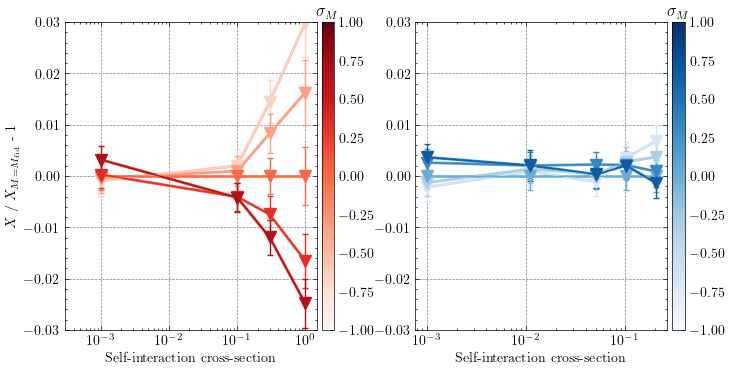

In [44]:
output_name = "pickles/mass_data_dependence.pkl"

mass_results = pkl.load(open(output_name, 'rb'))

fig, axarr = plt.subplots(1, 2, figsize=(8,4))
fig.subplots_adjust(wspace=.3)
color = {
    'src':colourFromRange([-1,n_mass_bins], cmap='Reds'),
    'tgt':colourFromRange([-1,n_mass_bins], cmap='Blues')
}
                           
                           
ref = {'src':np.mean(1-mass_results[2]['src']['thresholds'], axis=0),
       'tgt':np.mean(1-mass_results[2]['tgt']['thresholds'], axis=0)
      }

for imass_bin in tqdm(range(n_mass_bins)):
    
      
        
    for itgt, target in enumerate(['src','tgt']):
  
        ax = axarr[ itgt ]

        all_thresholds = mass_results[imass_bin][target]['thresholds']
        cross_sections =  mass_results[imass_bin][target]['cross_section']

            
        means = np.mean(1-all_thresholds,axis=0)
        errors = np.std(all_thresholds,axis=0)/np.sqrt(all_thresholds.shape[0])
  
        cross_sections  =  mass_results[imass_bin][target]['cross_section']
  
        
        ax.errorbar( cross_sections+1e-3, 
                    means/ref[target] -1,
                    errors/ref[target],
                    fmt='-v', label=f"${mass_cut[0]}$", 
                    capsize=2,
                    markersize=8, color=color[target][imass_bin])

       
            
            
        ax.set_xlabel("Self-interaction cross-section [cm$^2$/g]")
    
        points = np.column_stack([cross_sections+1e-3, means/ref[target]-1])          # shape (N, 2)
        segments = np.stack([points[:-1], points[1:]], axis=1)  # shape (N-1, 2, 2)

        lc = LineCollection(
                segments,
                cmap=color[target].cmap,
                norm=plt.Normalize(-1, 1 ),
                linewidths=2
            )

        lc.set_array(np.full(segments.shape[0], imass_bin/n_mass_bins-0.5))
        im2 = ax.add_collection(lc)


        ax.set_xscale('log')

        ax.set_xlabel("Self-interaction cross-section")
        if imass_bin == 0:
            if itgt == 0:
                ax.set_ylabel("Model threshold output")

        if imass_bin == n_mass_bins - 1:
            divider = make_axes_locatable(ax)
            cax = divider.append_axes('right', size='5%', pad=0.05)
            fig.colorbar(im2, cax=cax, orientation='vertical')           
            ax.text(1.04,1.02,"$\sigma_M$",transform=ax.transAxes,fontsize=12, ha='center')
        ax.set_ylim(-0.03,0.03)
axarr[0].set_ylabel("$X$ / $X_{M=M_{\\rm fid}}$ - 1")
fname = "plots/mass_dependency.pdf"
plt.savefig(fname)
os.system(f"pdfcrop {fname} {fname}")

# Dependence on the lower mass cut:

In [12]:


ifilter='concat'
all_results = pkl.load(open(f"pickles/all_models_{ifilter}_results.pkl",'rb'))

domain = {
    'tgt':'darkskies_obs',
    'src':'bahamas_obs'
}



color = {
    'src':'r',
    'tgt':'b'
}
n_mass_bins = 5

mass_bins = np.linspace(14.5,15.,n_mass_bins+1)

output_name = "pickles/mass_dependence.pkl"

if os.path.isfile(output_name):
    mass_results = pkl.load(open(output_name, 'rb'))
else:
    mass_results = {}


for imass_bin in tqdm(range(n_mass_bins)):
    mass_cut = [mass_bins[imass_bin], 16]
    
    ax = axarr[ imass_bin]
 
        
    for itgt, target in enumerate(['src','tgt']):
        try: 
            all_thresholds = mass_results[mass_bins[imass_bin]][target]['thresholds']
            cross_sections =  mass_results[mass_bins[imass_bin]][target]['cross_section']
        except:
            if mass_bins[imass_bin] not in mass_results.keys():
                mass_results[mass_bins[imass_bin]] = {'mass_cut':mass_cut}
                
            all_thresholds = []
            for imodel in all_results.keys():

            


                tgt = get_threshold_for_cross( 
                    all_results[imodel][target], 
                    mass_cut=mass_cut, 
                    dataset=domain[target].split('_')[0],
                    quiet=False,
                function=np.median)



                all_thresholds.append(tgt['thresholds'])

            all_thresholds = np.array(all_thresholds)
            mass_results[mass_bins[imass_bin]][target] = {'thresholds': all_thresholds, 'cross_section':tgt['cross_sections']}
            
pkl.dump(mass_results, open( output_name,'wb'))

100%|████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:00<00:00, 119156.36it/s]


## Divided in to plots of mass bins

100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:00<00:00, 446.26it/s]


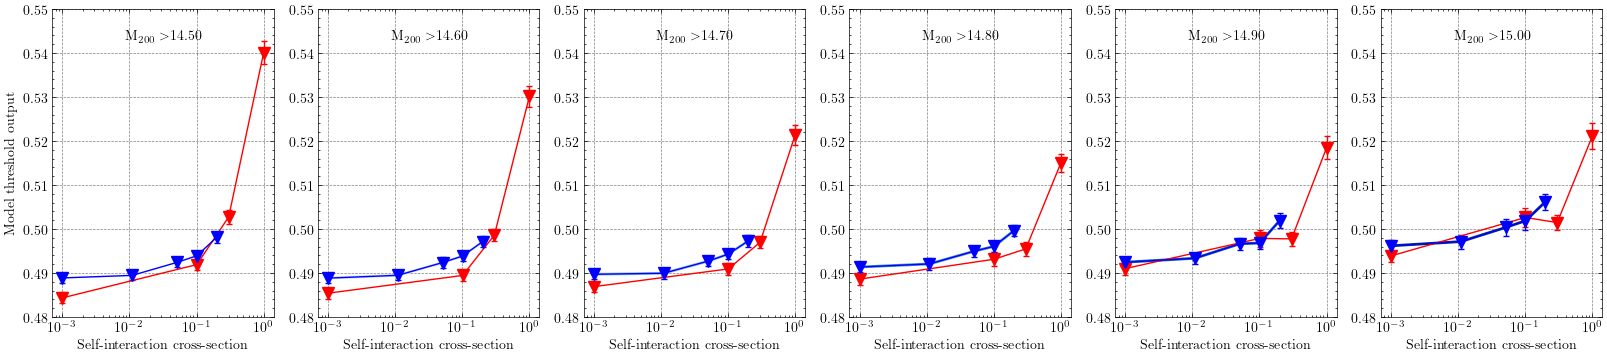

In [32]:

color = {
    'src':'r',
    'tgt':'b'
}


mass_results = pkl.load(open(output_name, 'rb'))

mass_bins = np.array(list(mass_results.keys()))
mass_bins = mass_bins[ mass_bins<=15]
n_mass_bins = mass_bins.shape[0]

fig, axarr = plt.subplots(1, n_mass_bins, figsize=(20,4))

for imass_bin in tqdm(range(n_mass_bins)):
    mass_cut = [mass_bins[imass_bin], 16]
    
    ax = axarr[ imass_bin]
 
        
    for itgt, target in enumerate(['src','tgt']):

        all_thresholds = mass_results[mass_bins[imass_bin]][target]['thresholds']
        cross_sections =  mass_results[mass_bins[imass_bin]][target]['cross_section']
       
        means = np.mean(1-all_thresholds,axis=0)
        errors = np.std(all_thresholds,axis=0)/np.sqrt(all_thresholds.shape[0])
  
        cross_sections  =  mass_results[mass_bins[imass_bin]][target]['cross_section']
        ax.errorbar( cross_sections+1e-3, 
                    means,
                    errors,
                    fmt='-v', label=f"${mass_cut[0]}$", 
                    capsize=2,
                    markersize=8, color=color[target])

        ax.set_xlabel("Self-interaction cross-section [cm$^2$/g]")
    
    points = np.column_stack([cross_sections+1e-3, means])          # shape (N, 2)
    segments = np.stack([points[:-1], points[1:]], axis=1)  # shape (N-1, 2, 2)

    lc = LineCollection(
            segments,
            cmap='Blues',
            norm=plt.Normalize(mass_bins[0], mass_bins[-1]),
            linewidths=2
        )

    lc.set_array(np.full(segments.shape[0], mass_bins[imass_bin]))
    im2 = ax.add_collection(lc)

    ax.text( 0.5,0.9 ,f"M$_{{200}}>${mass_bins[imass_bin]:0.2f}", transform=ax.transAxes, ha='center')

    ax.set_xscale('log')
    
    ax.set_xlabel("Self-interaction cross-section")
    if imass_bin == 0:
        ax.set_ylabel("Model threshold output")
    #divider = make_axes_locatable(ax)
    #cax = divider.append_axes('right', size='5%', pad=0.05)
    #fig.colorbar(im2, cax=cax, orientation='vertical')           
    ax.set_ylim(0.48,0.55)


## Divided in to plots os taret bins

100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:00<00:00, 231.34it/s]


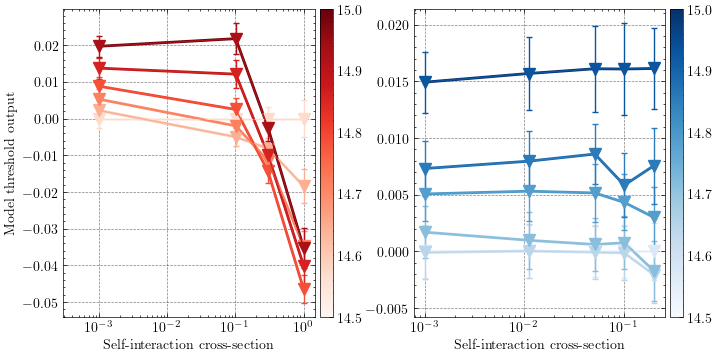

In [49]:
mass_results = pkl.load(open(output_name, 'rb'))

mass_bins = np.array(list(mass_results.keys()))
mass_bins = mass_bins[ mass_bins<=15]

n_mass_bins = mass_bins.shape[0]

fig, axarr = plt.subplots(1, 2, figsize=(8,4))
fig.subplots_adjust(wspace=.3)
color = {
    'src':colourFromRange([-1,n_mass_bins], cmap='Reds'),
    'tgt':colourFromRange([-1,n_mass_bins], cmap='Blues')
}
                           
                           
ref = {}

for imass_bin in tqdm(range(n_mass_bins)):
    mass_cut = [mass_bins[imass_bin], 16]
    
      
        
    for itgt, target in enumerate(['src','tgt']):
  
        ax = axarr[ itgt ]

        all_thresholds = mass_results[mass_bins[imass_bin]][target]['thresholds']
        cross_sections =  mass_results[mass_bins[imass_bin]][target]['cross_section']

            
        means = np.mean(1-all_thresholds,axis=0)
        errors = np.std(all_thresholds,axis=0)/np.sqrt(all_thresholds.shape[0])
  
        cross_sections  =  mass_results[mass_bins[imass_bin]][target]['cross_section']
        if imass_bin == 0:
            ref[target] = means
        
        ax.errorbar( cross_sections+1e-3, 
                    means/ref[target] -1,
                    errors/ref[target],
                    fmt='-v', label=f"${mass_cut[0]}$", 
                    capsize=2,
                    markersize=8, color=color[target][imass_bin])

       
            
            
        ax.set_xlabel("Self-interaction cross-section [cm$^2$/g]")
    
        points = np.column_stack([cross_sections+1e-3, means/ref[target]-1])          # shape (N, 2)
        segments = np.stack([points[:-1], points[1:]], axis=1)  # shape (N-1, 2, 2)

        lc = LineCollection(
                segments,
                cmap=color[target].cmap,
                norm=plt.Normalize(mass_bins[0], mass_bins[-1]),
                linewidths=2
            )

        lc.set_array(np.full(segments.shape[0], mass_bins[imass_bin]))
        im2 = ax.add_collection(lc)


        ax.set_xscale('log')

        ax.set_xlabel("Self-interaction cross-section")
        if imass_bin == 0:
            if itgt == 0:
                ax.set_ylabel("Model threshold output")

        if imass_bin == n_mass_bins - 1:
            divider = make_axes_locatable(ax)
            cax = divider.append_axes('right', size='5%', pad=0.05)
            fig.colorbar(im2, cax=cax, orientation='vertical')           
            